# Notebook 7 (V4_3) — Numerical Verification of the Equilibrium Assumptions

`Reference_draft/V4_3_production.tex` proves the production-side bubble theorem
(`thm_prod_sufficient`, line 2325) under **three layers** of hypotheses
(see the draft's own taxonomy at line 2322):

1. **Primitive** restrictions (preferences, regime switching, CES, productivity
   maps, issuance costs) — true by construction of the calibration.
2. **Equilibrium-selection** conditions — properties of the *selected* Markov
   competitive equilibrium: `ass_pathwise_interior_innovation`,
   `ass_absorbing_stationary_equilibrium_selection`.
3. **Branch-regularity & technical-sign** conditions imposed on the selected
   path: `ass_regular_kernel`, `ass_interior_equity_weights`,
   `ass_us_u_allocation_upper_regular`, `ass_us_income_growth_regular`,
   `ass_rf_lower_bound`, `ass_positive_u_total_saving_return`.

Layers 2–3 are **not derivable from primitives** — the draft states (line 2322):
*"these regularity conditions … summarize equilibrium properties that are needed
for the bubble-existence argument and are not derived from the current primitive
block."* This notebook **numerically verifies** every such assumption on the
solved equilibrium, and (bonus) checks the order conclusions of the supporting
lemmas. This both validates the maintained hypotheses behind the bubble theorem
and quantifies how tight the one-sided orders are (which motivates the
order-notation in the other notebooks).

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")
using Plots, LaTeXStrings, Printf, Statistics
gr()

result = run_production_simulation(ProductionParams(T_max=100); verbose=false)
p, u_path, bgp_seq = result.params, result.u_path, result.bgp_seq
diag = result.diagnostics
T = length(u_path); tt = 1:T
ψ_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
pass(b) = b ? "✓ PASS" : "✗ FAIL"
checks = Tuple{String,Bool,String}[]     # (assumption, pass, detail)
@printf("Solved: converged=%s  max‖F_u‖=%.2e  ν_b=%.5f\n",
        result.branch_converged, result.max_u_residual, p.ν_b)

  Activating 

Solved: converged=true  max‖F_u‖=3.94e-08  ν_b=0.08172


project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


## 1. Equilibrium-Selection Conditions

In [2]:
# ass_pathwise_interior_innovation: 0 < φ_{i,t} < 1 (u-branch and BGP)
φmin  = minimum(min(s.φ_US, s.φ_W) for s in u_path)
φmax  = maximum(max(s.φ_US, s.φ_W) for s in u_path)
φbmin = minimum(min(b.φ_US, b.φ_W) for b in bgp_seq)
φbmax = maximum(max(b.φ_US, b.φ_W) for b in bgp_seq)
a1 = 0 < min(φmin,φbmin) && max(φmax,φbmax) < 1
push!(checks, ("ass_pathwise_interior_innovation", a1,
      @sprintf("φ^u∈(%.4f,%.4f), φ^b∈(%.4f,%.4f) ⊂ (0,1)", φmin,φmax,φbmin,φbmax)))

# ass_absorbing_stationary_equilibrium_selection: interior φ_b + G_b=G_W.
# ν_b is calibrated once at the initial state, so the common-growth condition
# holds at machine precision there and drifts only negligibly off it.
gap_calib = bgp_seq[1].G_N_US^p.ν_b - bgp_seq[1].G_N_W^p.ξ_W
gap_max   = maximum(abs(b.G_N_US^p.ν_b - b.G_N_W^p.ξ_W) for b in bgp_seq)
a2 = abs(gap_calib) < 1e-6 && φbmin > 0 && φbmax < 1
push!(checks, ("ass_absorbing_stationary_equilibrium_selection", a2,
      @sprintf("G_b−G_W: calib=%.2e, max drift=%.2e; φ_b interior", gap_calib, gap_max)))

for ch in checks[end-1:end]; @printf("[%s] %-50s %s\n", pass(ch[2]), ch[1], ch[3]); end

[✓ PASS] ass_pathwise_interior_innovation                   φ^u∈(0.0359,0.7244), φ^b∈(0.6626,0.7263) ⊂ (0,1)
[✓ PASS] ass_absorbing_stationary_equilibrium_selection     G_b−G_W: calib=1.22e-09, max drift=6.95e-05; φ_b interior


## 2. Branch-Regularity and Technical-Sign Conditions

The six regularity/sign conditions of `thm_prod_sufficient` (line 2333), plus the
maintained interiority of the pre-switch US bond-share FOC.

In [3]:
# ass_regular_kernel: Ψ_t > 0 (u-branch and BGP)
ψ_min_all = min(diag.psi_min, minimum(b.Psi for b in bgp_seq))
a3 = ψ_min_all > 0
push!(checks, ("ass_regular_kernel (Ψ_t>0)", a3, @sprintf("min Ψ = %.4e", ψ_min_all)))

# ass_interior_equity_weights: ω, ω* ∈ [λ, 1-λ] (u and b)
ew_u = minimum(min(s.ω,1-s.ω,s.ω_star,1-s.ω_star) for s in u_path)
ew_b = minimum(min(b.ω,1-b.ω,b.ω_star,1-b.ω_star) for b in bgp_seq)
a4 = min(ew_u, ew_b) > 0
push!(checks, ("ass_interior_equity_weights", a4,
      @sprintf("min slack=%.4e (u=%.4e, b=%.4e)", min(ew_u,ew_b), ew_u, ew_b)))

# ass_us_u_allocation_upper_regular: φ_US^u ≤ φ̄_u < 1
φUSmax = maximum(s.φ_US for s in u_path)
a5 = φUSmax < 1
push!(checks, ("ass_us_u_allocation_upper_regular", a5,
      @sprintf("max φ_US^u = %.4f < 1 (φ̄_u≈%.4f)", φUSmax, φUSmax)))

# ass_us_income_growth_regular: bounded gross e^u growth
eg = [u_path[t].e_US/u_path[t-1].e_US for t in 2:T]
a6 = all(isfinite, eg) && minimum(eg) > 0
push!(checks, ("ass_us_income_growth_regular", a6,
      @sprintf("e^u_t/e^u_{t-1} ∈ [%.4f, %.4f]", minimum(eg), maximum(eg))))

# ass_rf_lower_bound: R_f ≥ R_f̲ > 0 (the switch branch reuses the same R_{f,t})
Rfmin = minimum(s.R_f for s in u_path)
a7 = Rfmin > 0
push!(checks, ("ass_rf_lower_bound", a7, @sprintf("min R_f = %.4f > 0", Rfmin)))

# ass_positive_u_total_saving_return
Rp_min = minimum(s.R_p_u for s in u_path)
θ_min  = minimum(s.θ for s in u_path)
Rf_max = maximum(s.R_f for s in u_path)
comp   = min(Rp_min, (1-θ_min)*Rp_min + θ_min*Rf_max)
a8 = comp > 0
push!(checks, ("ass_positive_u_total_saving_return", a8,
      @sprintf("min{R_p̲=%.4f, (1−θ̲)R_p̲+θ̲R̄_f=%.4f}=%.4f>0", Rp_min, (1-θ_min)*Rp_min+θ_min*Rf_max, comp)))

# pre-switch US bond-share FOC interior: θ_t^u < 0 strictly
θmax = maximum(s.θ for s in u_path)
a9 = θmax < 0
push!(checks, ("pre-switch bond-FOC interior (θ^u<0)", a9, @sprintf("max θ^u = %.4f < 0", θmax)))

for ch in checks[end-6:end]; @printf("[%s] %-50s %s\n", pass(ch[2]), ch[1], ch[3]); end

[✓ PASS] ass_regular_kernel (Ψ_t>0)                         min Ψ = 9.8357e-01
[✓ PASS] ass_interior_equity_weights                        min slack=2.4448e-02 (u=2.4448e-02, b=1.7017e-01)
[✓ PASS] ass_us_u_allocation_upper_regular                  max φ_US^u = 0.6638 < 1 (φ̄_u≈0.6638)
[✓ PASS] ass_us_income_growth_regular                       e^u_t/e^u_{t-1} ∈ [1.0177, 1.0361]
[✓ PASS] ass_rf_lower_bound                                 min R_f = 0.6570 > 0
[✓ PASS] ass_positive_u_total_saving_return                 min{R_p̲=0.9114, (1−θ̲)R_p̲+θ̲R̄_f=0.7884}=0.7884>0
[✓ PASS] pre-switch bond-FOC interior (θ^u<0)               max θ^u = -0.0364 < 0


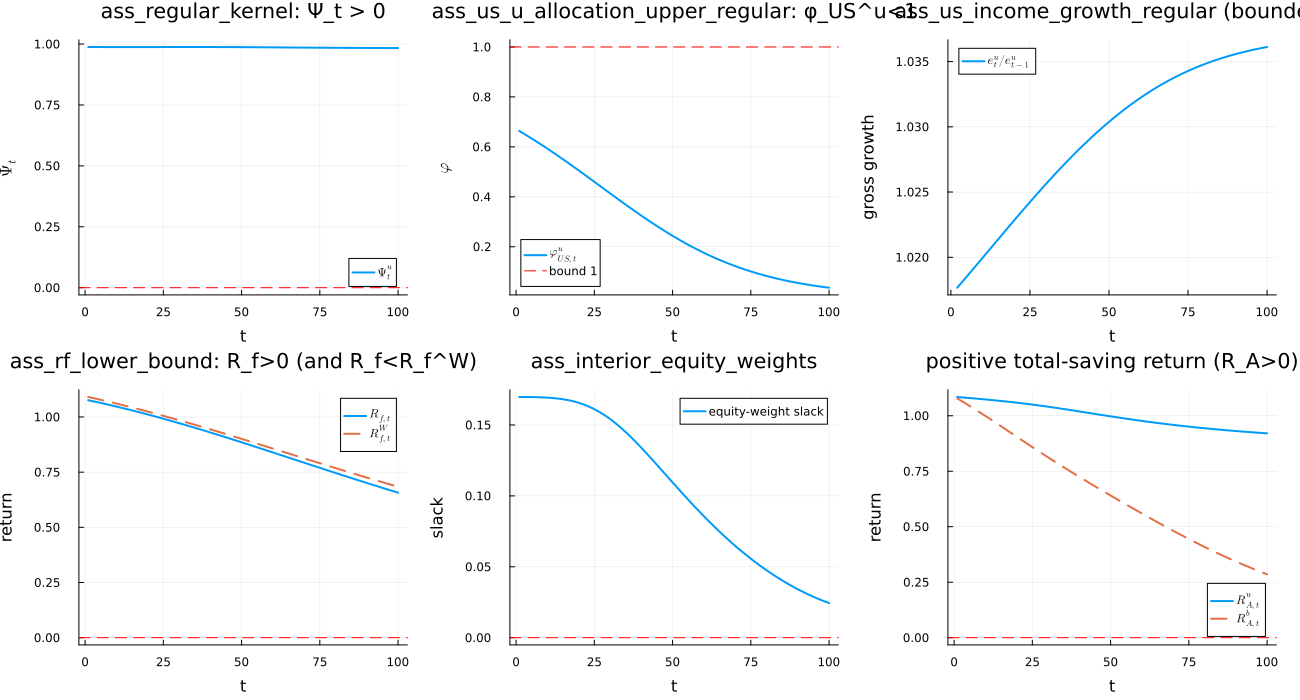

In [4]:
ψ_path = [s.Psi for s in u_path]
g1 = plot(tt, ψ_path, lw=2, label=L"\Psi_t^u", xlabel="t", ylabel=L"\Psi_t",
          title="ass_regular_kernel: Ψ_t > 0"); hline!(g1, [0], ls=:dash, lc=:red, label="")
g2 = plot(tt, [s.φ_US for s in u_path], lw=2, label=L"\varphi_{US,t}^u", xlabel="t", ylabel=L"\varphi",
          title="ass_us_u_allocation_upper_regular: φ_US^u<1")
hline!(g2, [1.0], ls=:dash, lc=:red, label="bound 1")
g3 = plot(2:T, eg, lw=2, label=L"e_t^u/e_{t-1}^u", xlabel="t", ylabel="gross growth",
          title="ass_us_income_growth_regular (bounded)")
g4 = plot(tt, [s.R_f for s in u_path], lw=2, label=L"R_{f,t}", xlabel="t", ylabel="return",
          title="ass_rf_lower_bound: R_f>0 (and R_f<R_f^W)")
plot!(g4, tt, [s.R_f_W for s in u_path], lw=2, ls=:dash, label=L"R_{f,t}^W")
hline!(g4, [0], ls=:dash, lc=:red, label="")
g5 = plot(tt, [min(s.ω,1-s.ω,s.ω_star,1-s.ω_star) for s in u_path], lw=2,
          label="equity-weight slack", xlabel="t", ylabel="slack",
          title="ass_interior_equity_weights"); hline!(g5, [0], ls=:dash, lc=:red, label="")
g6 = plot(tt, [s.R_A_u for s in u_path], lw=2, label=L"R_{A,t}^u", xlabel="t", ylabel="return",
          title="positive total-saving return (R_A>0)")
plot!(g6, tt, [s.R_A_b for s in u_path], lw=2, ls=:dash, label=L"R_{A,t}^b")
hline!(g6, [0], ls=:dash, lc=:red, label="")
plot(g1,g2,g3,g4,g5,g6, layout=(2,3), size=(1300, 700), margin=4Plots.mm)

## 3. Lemma Order-Conclusions (bonus; bridges to the order-notation fixes)

`lem_prod_orders` proves only **one-sided** orders for the u-branch endogenous
objects ($\varphi_{US}^u\lesssim N^{-\psi_{US}/\rho_{US}}$,
$e^u\gtrsim N^{\nu_u}$, $q^u\asymp e^u/N$) because they are equilibrium objects,
not primitives. We fit log-log slopes to see whether the bounds are tight.

In [5]:
N  = [s.N_US for s in u_path]
Nb = [b.N_US for b in bgp_seq]
slope(x,y,r) = (lx=log.(x[r]); ly=log.(y[r]); lx0=lx.-mean(lx); sum(lx0.*(ly.-mean(ly)))/sum(lx0.^2))

qN_e   = [u_path[t].q_US*N[t]/u_path[t].e_US for t in 1:T]
φv     = [s.φ_US for s in u_path]
s_phiF = slope(N, φv, 1:T)
s_phiL = slope(N, φv, (T-10):T)
s_e    = slope(N, [s.e_US for s in u_path], 1:T)
s_qdb  = slope(Nb, [b.q_US+b.d_US for b in bgp_seq], 1:length(Nb))
dqb    = [b.d_US/b.q_US for b in bgp_seq]
println("lem_prod_orders:")
@printf("  q^u≍e^u/N       : q·N/e ∈ [%.4f,%.4f] (two-sided; const varies %.1f×)\n",
        minimum(qN_e), maximum(qN_e), maximum(qN_e)/minimum(qN_e))
@printf("  φ_US^u ≲ N^{-ψ/ρ}: slope full=%.4f, late=%.4f vs bound −ψ/ρ=%.4f (≲ holds)\n",
        s_phiF, s_phiL, -ψ_US/p.ρ_US)
@printf("  d^u/q^u ≲ N^{-ψ/ρ}: same slope (d/q = a(1−ϑ)/ϑ·φ·H ∝ φ exactly)\n")
@printf("  e^u ≳ N^{ν_u}    : slope=%.4f ≥ ν_u=%.4f (≳ holds, not tight)\n", s_e, p.ν_u)
@printf("  q^b+d^b ≍ N^{ν_b−1}: slope=%.4f vs ν_b−1=%.4f (tight) | d^b/q^b∈[%.4f,%.4f]\n",
        s_qdb, p.ν_b-1, minimum(dqb), maximum(dqb))

ℓ   = [bgp_seq[t].e_US/u_path[t-1].e_US for t in 2:T]
RbN = [u_path[t].R_p_b/ℓ[t-1] for t in 2:T]
δ   = minimum(u_path[t].R_A_b/u_path[t].R_p_b for t in 1:T)
Cu_e  = [u_path[t-1].A*u_path[t-1].R_A_u/u_path[t].e_US for t in 2:T]
Cb_eb = [u_path[t-1].A*u_path[t-1].R_A_b/bgp_seq[t].e_US for t in 2:T]
println("\nsupporting lemmas:")
@printf("  lem_risky_return_bounds : R_A^u∈[%.3f,%.3f]≍1 ; R_p^b/ℓ_t∈[%.3f,%.3f] (≍ℓ_t)\n",
        minimum(s.R_A_u for s in u_path), maximum(s.R_A_u for s in u_path), minimum(RbN), maximum(RbN))
@printf("  lem_rf_upper_bound      : max R_f=%.3f<∞ ; R_f<R_f^W ∀t=%s (exorbitant privilege)\n",
        Rf_max, all(s.R_f < s.R_f_W for s in u_path))
@printf("  lem_US_bond_share_lower : θ^u ≥ %.4f (bounded below)\n", θ_min)
@printf("  lem_uniform_natural_debt_slack : min R_A^b/R_p^b = %.4f > 0 (δ̲)\n", δ)
@printf("  lem_total_return_consumption   : C^u/e^u∈[%.3f,%.3f] ; C^b/e^b∈[%.3f,%.3f]\n",
        minimum(Cu_e),maximum(Cu_e),minimum(Cb_eb),maximum(Cb_eb))
@printf("  lem_stock_value_bounds  : Q_US/e∈[%.3f,%.3f] ; Q_W/e∈[%.3f,%.3f]\n",
        minimum(s.Q_US/s.e_US for s in u_path), maximum(s.Q_US/s.e_US for s in u_path),
        minimum(s.Q_W/s.e_US for s in u_path), maximum(s.Q_W/s.e_US for s in u_path))

lem_prod_orders:
  q^u≍e^u/N       : q·N/e ∈ [0.2557,0.5095] (two-sided; const varies 2.0×)
  φ_US^u ≲ N^{-ψ/ρ}: slope full=-0.2220, late=-0.2441 vs bound −ψ/ρ=-0.2500 (≲ holds)
  d^u/q^u ≲ N^{-ψ/ρ}: same slope (d/q = a(1−ϑ)/ϑ·φ·H ∝ φ exactly)
  e^u ≳ N^{ν_u}    : slope=0.2149 ≥ ν_u=0.2000 (≳ holds, not tight)
  q^b+d^b ≍ N^{ν_b−1}: slope=-0.9193 vs ν_b−1=-0.9183 (tight) | d^b/q^b∈[0.1325,0.1335]

supporting lemmas:
  lem_risky_return_bounds : R_A^u∈[0.921,1.084]≍1 ; R_p^b/ℓ_t∈[1.065,1.699] (≍ℓ_t)
  lem_rf_upper_bound      : max R_f=1.076<∞ ; R_f<R_f^W ∀t=true (exorbitant privilege)
  lem_US_bond_share_lower : θ^u ≥ -0.7484 (bounded below)
  lem_uniform_natural_debt_slack : min R_A^b/R_p^b = 0.9298 > 0 (δ̲)
  lem_total_return_consumption   : C^u/e^u∈[0.445,0.533] ; C^b/e^b∈[0.536,0.828]
  lem_stock_value_bounds  : Q_US/e∈[0.305,0.544] ; Q_W/e∈[0.267,0.462]


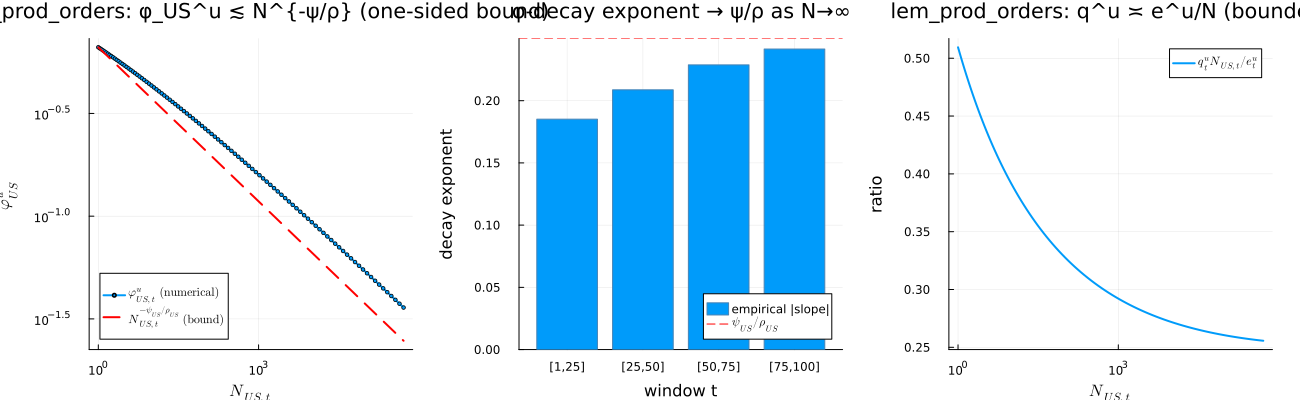

In [6]:
bound = φv[1] .* (N ./ N[1]).^(-ψ_US/p.ρ_US)
o1 = plot(N, φv, lw=2, marker=:circle, ms=2, xscale=:log10, yscale=:log10,
          label=L"\varphi_{US,t}^u\ \mathrm{(numerical)}", xlabel=L"N_{US,t}", ylabel=L"\varphi_{US}^u",
          title="lem_prod_orders: φ_US^u ≲ N^{-ψ/ρ} (one-sided bound)", legend=:bottomleft)
plot!(o1, N, bound, lw=2, ls=:dash, lc=:red,
      label=L"N_{US,t}^{-\psi_{US}/\rho_{US}}\ \mathrm{(bound)}")

wins   = [(1,25),(25,50),(50,75),(75,T)]
slopes = [-slope(N, φv, lo:hi) for (lo,hi) in wins]
o2 = bar(["[$lo,$hi]" for (lo,hi) in wins], slopes, lc=:steelblue, legend=:bottomright,
         label="empirical |slope|", xlabel="window t", ylabel="decay exponent",
         title="φ-decay exponent → ψ/ρ as N→∞")
hline!(o2, [ψ_US/p.ρ_US], ls=:dash, lc=:red, label=L"\psi_{US}/\rho_{US}")

o3 = plot(N, qN_e, lw=2, xscale=:log10, label=L"q_t^u N_{US,t}/e_t^u",
          xlabel=L"N_{US,t}", ylabel="ratio", title="lem_prod_orders: q^u ≍ e^u/N (bounded)")
plot(o1, o2, o3, layout=(1,3), size=(1300, 400), margin=5Plots.mm)

## 4. Consolidated Verification

In [7]:
println("═"^80)
println("V4_3 ASSUMPTION VERIFICATION — baseline HKT-matched calibration")
println("═"^80)
for ch in checks
    @printf("  [%s] %-48s %s\n", pass(ch[2]), ch[1], ch[3])
end
@printf("\n  %d / %d equilibrium-selection & regularity assumptions PASS\n",
        count(ch->ch[2], checks), length(checks))
println("─"^80)
println("Bridge to the order-notation fixes (Task 3):")
println("  V4_3 lem_prod_orders proves only one-sided orders for u-branch endogenous")
println("  objects — φ_US^u ≲ N^{-ψ/ρ} and e^u ≳ N^{ν_u} — because they are equilibrium")
println("  objects, not primitives.")
@printf("  Numerically: φ_US^u decays at slope %.3f (full path), steepening to %.3f near\n", s_phiF, s_phiL)
@printf("  the horizon → the bound exponent ψ/ρ=%.3f is approached from below but is NOT\n", ψ_US/p.ρ_US)
println("  two-sided-tight at finite t. This is exactly why the draft writes ≲, not ≍.")

════════════════════════════════════════════════════════════════════════════════
V4_3 ASSUMPTION VERIFICATION — baseline HKT-matched calibration
════════════════════════════════════════════════════════════════════════════════
  [✓ PASS] ass_pathwise_interior_innovation                 φ^u∈(0.0359,0.7244), φ^b∈(0.6626,0.7263) ⊂ (0,1)
  [✓ PASS] ass_absorbing_stationary_equilibrium_selection   G_b−G_W: calib=1.22e-09, max drift=6.95e-05; φ_b interior
  [✓ PASS] ass_regular_kernel (Ψ_t>0)                       min Ψ = 9.8357e-01
  [✓ PASS] ass_interior_equity_weights                      min slack=2.4448e-02 (u=2.4448e-02, b=1.7017e-01)
  [✓ PASS] ass_us_u_allocation_upper_regular                max φ_US^u = 0.6638 < 1 (φ̄_u≈0.6638)
  [✓ PASS] ass_us_income_growth_regular                     e^u_t/e^u_{t-1} ∈ [1.0177, 1.0361]
  [✓ PASS] ass_rf_lower_bound                               min R_f = 0.6570 > 0
  [✓ PASS] ass_positive_u_total_saving_return               min{R_p̲=0.9114, (1−θ̲)R